# Level 3 - Task 1

## Predictive Modeling

### Objective

Build regression models to predict restaurant aggregate ratings and compare model performance using different machine learning algorithms.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("Dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset.csv'

In [3]:
df = pd.read_csv("Dataset .csv")

In [4]:
df = df.dropna(subset=['Cuisines'])

In [5]:
df["Table Booking Encoded"] = (
    df["Has Table booking"]
    .map({"Yes":1,"No":0})
)

df["Online Delivery Encoded"] = (
    df["Has Online delivery"]
    .map({"Yes":1,"No":0})
)

In [6]:
features = [
    "Country Code",
    "Longitude",
    "Latitude",
    "Average Cost for two",
    "Price range",
    "Votes",
    "Table Booking Encoded",
    "Online Delivery Encoded"
]

X = df[features]

y = df["Aggregate rating"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7633, 8)
(1909, 8)


In [8]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [9]:
print("Linear Regression")

print(
    "MAE:",
    mean_absolute_error(y_test, lr_predictions)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            lr_predictions
        )
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        lr_predictions
    )
)

Linear Regression
MAE: 1.024485722068294
RMSE: 1.238977405888194
R2 Score: 0.3296753593518199


In [10]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_predictions = dt_model.predict(
    X_test
)

In [11]:
print("Decision Tree")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        dt_predictions
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            dt_predictions
        )
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        dt_predictions
    )
)

Decision Tree
MAE: 0.27642744892613935
RMSE: 0.4320877721593837
R2 Score: 0.9184728307502495


In [12]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

In [13]:
print("Random Forest")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        rf_predictions
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            rf_predictions
        )
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        rf_predictions
    )
)

Random Forest
MAE: 0.20151935568360402
RMSE: 0.3083638254784691
R2 Score: 0.9584773310976106


In [14]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score":[
        r2_score(y_test, lr_predictions),
        r2_score(y_test, dt_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.329675
1      Decision Tree  0.918473
2      Random Forest  0.958477


<Axes: xlabel='Model'>

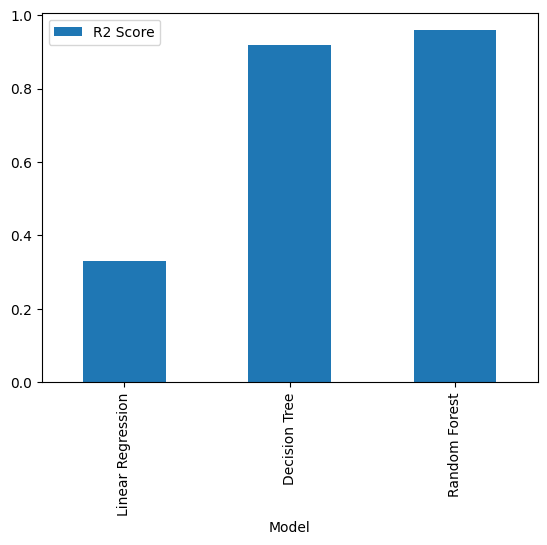

In [15]:
results.plot(
    x="Model",
    y="R2 Score",
    kind="bar"
)